# Trabajo Práctico 2 - Grupo 02

### Modelo XLM-RoBERTa-Base — Split limpio + EDA augmentation (solo train fold)

Integrantes:

*   Bermudez, Agustin
*   Calderón, Tiago
*   Gonzalez Pautaso, Mateo
*   Moreyra, Santiago
*   Nieves, Maylen

**Modelo:** `xlm-roberta-base` (278M parámetros, multilingüe, Meta AI)

**Dataset:** train original + muestras EDA extraídas de `train_augmented_eda_balanced.csv`,
aplicadas **únicamente sobre el fold de entrenamiento** para evitar contaminación del validation set.

**Mejoras v2 (class weights + mayor capacidad):**
1. **Class weights [1.0, 2.5, 1.0]**: penaliza 2.5× los errores en clase neutra (bottleneck: F1=0.459 en v1).
2. **max_length 128 → 256**: captura contexto completo de reseñas largas.
3. **epochs 3 → 5** con early stopping patience=2.
4. **lr 2e-5 → 1.5e-5**: entrenamiento más fino con más epochs.

**Hiperparámetros:** `lr=1.5e-5` | `epochs=5` | `max_length=256` | `batch_size=32` | `class_weights=[1.0, 2.5, 1.0]`

## 1. Setup

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
if torch.cuda.is_available():
    print("CUDA/ROCm disponible")
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Sin GPU CUDA/ROCm — se usará CPU (entrenamiento lento)")

CUDA/ROCm disponible
GPU: AMD Radeon RX 9070 XT
VRAM: 17.1 GB


## 2. Imports y funciones auxiliares

In [2]:
import sys
sys.path.insert(0, "../../..")

import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from common.data_utils import get_split, SEED
from common.preprocessing import clean_minimal
from common.evaluation import evaluate

np.random.seed(SEED)
torch.manual_seed(SEED)

CLASS_NAMES = ["negativa", "neutra", "positiva"]
print("Imports OK")

Imports OK


## 3. Configuración

In [3]:
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_FP16      = torch.cuda.is_available()
MODEL_NAME    = "xlm-roberta-base"
MAX_LENGTH    = 256
BATCH_SIZE    = 32
NUM_EPOCHS    = 5
LR            = 1.5e-5
CLASS_WEIGHTS = [1.0, 2.5, 1.0]   # [neg, neu, pos] — neutra penalizada 2.5×
SAVE_NAME     = "red_neuronal_xlm_roberta_n12_clean_split"

print(f"Device:         {DEVICE}")
print(f"fp16:           {USE_FP16}")
print(f"Modelo:         {MODEL_NAME}")
print(f"Config:         lr={LR} | epochs={NUM_EPOCHS} | max_length={MAX_LENGTH} | batch={BATCH_SIZE}")
print(f"Class weights:  {CLASS_WEIGHTS}")

Device:         cuda
fp16:           True
Modelo:         xlm-roberta-base
Config:         lr=1.5e-05 | epochs=5 | max_length=256 | batch=32
Class weights:  [1.0, 2.5, 1.0]


## 4. Carga de datos con split limpio

### Estrategia (corrige el leakage de versiones anteriores)

```
train.csv (51,000 reales)
    ↓ get_split()
    ├── train_orig (40,800 reales) ──┐
    │                                │
    └── val_clean (10,200 reales)    │ + EDA aug (solo clases muestreadas del train)
                                     ↓
                               df_train_final (~54,000)
```

El val set contiene **únicamente** muestras reales de `train.csv`.

In [4]:
# 1. Cargar datos originales
df_original = pd.read_csv("../../../data/train.csv")
test_df     = pd.read_csv("../../../data/test.csv")
original_ids = set(df_original["id"])

print(f"Dataset original: {len(df_original):,} filas")
print(f"Distribución:\n{df_original['label'].value_counts().sort_index()}")

# 2. Split ANTES de augmentar (val set = 100% datos reales)
X_train_orig, X_val_raw, y_train_orig, y_val = get_split(df_original)
print(f"\nSplit limpio: {len(X_train_orig):,} train | {len(X_val_raw):,} val")

# 3. Extraer muestras EDA (NO pertenecen al original)
df_eda_full  = pd.read_csv("../../../data/train_augmented_eda_balanced.csv")
df_aug_only  = df_eda_full[~df_eda_full["id"].isin(original_ids)].copy()
print(f"\nMuestras EDA disponibles: {len(df_aug_only):,}")
print(f"Distribución EDA:\n{df_aug_only['label'].value_counts().sort_index()}")

# 4. Combinar train original + EDA aug
df_train_final = pd.concat([
    pd.DataFrame({"text": X_train_orig, "label": y_train_orig}),
    df_aug_only[["text", "label"]]
], ignore_index=True)

y_train_final = df_train_final["label"].values.astype(int)

print(f"\nTrain final: {len(df_train_final):,} filas")
print(f"Distribución train final:\n{df_train_final['label'].value_counts().sort_index()}")

# Verificación: confirmar que no hay overlap entre EDA aug y val
aug_texts = set(df_aug_only["text"].values)
val_texts = set(X_val_raw)
overlap = aug_texts.intersection(val_texts)
assert len(overlap) == 0, f"ERROR: {len(overlap)} muestras de aug presentes en val!"
print(f"\n✓ Anti-leakage check OK: 0 muestras aug en val set")
print(f"✓ Val set: {len(X_val_raw):,} muestras 100% reales")

Dataset original: 51,000 filas
Distribución:
label
0    20400
1    10200
2    20400
Name: count, dtype: int64

Split limpio: 40,800 train | 10,200 val

Muestras EDA disponibles: 16,000
Distribución EDA:
label
0     2000
1    12000
2     2000
Name: count, dtype: int64

Train final: 56,800 filas
Distribución train final:
label
0    18320
1    20160
2    18320
Name: count, dtype: int64

✓ Anti-leakage check OK: 0 muestras aug en val set
✓ Val set: 10,200 muestras 100% reales


In [5]:
print("Aplicando clean_minimal...")
X_train = np.array([clean_minimal(t) for t in df_train_final["text"].values])
X_val   = np.array([clean_minimal(t) for t in X_val_raw])
X_test  = np.array([clean_minimal(t) for t in test_df["text"].values])
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Aplicando clean_minimal...
Train: 56,800 | Val: 10,200 | Test: 8,500


## 5. Tokenización

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Ejemplo de tokenización:")
for t in ["No funciona bien, muy decepcionante.", "Excelente producto, lo recomiendo."]:
    print(f"  '{t}' -> {tokenizer.tokenize(t)}")


class ResenasDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=128):
        self.encodings = tokenizer(
            list(texts), truncation=True,
            padding="max_length", max_length=max_length,
            return_tensors="pt",
        )
        self.labels = labels

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


print("\nTokenizando...")
train_dataset = ResenasDataset(X_train, y_train_final, tokenizer, MAX_LENGTH)
val_dataset   = ResenasDataset(X_val,   y_val,         tokenizer, MAX_LENGTH)
test_dataset  = ResenasDataset(X_test,  None,          tokenizer, MAX_LENGTH)
print("Listo.")

Ejemplo de tokenización:
  'No funciona bien, muy decepcionante.' -> ['▁No', '▁funciona', '▁bien', ',', '▁muy', '▁decepcion', 'ante', '.']
  'Excelente producto, lo recomiendo.' -> ['▁Excelente', '▁producto', ',', '▁lo', '▁recomiendo', '.']

Tokenizando...
Listo.


## 6. Modelo y métricas

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {total:,}")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1_per = f1_score(labels, preds, average=None, zero_division=0)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_neg": float(f1_per[0]),
        "f1_neu": float(f1_per[1]),
        "f1_pos": float(f1_per[2]),
    }


class WeightedTrainer(Trainer):
    """Trainer con CrossEntropyLoss ponderada por clase."""
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        weight = torch.tensor(self.class_weights, dtype=torch.float32, device=outputs.logits.device)
        loss = nn.CrossEntropyLoss(weight=weight)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


print(f"WeightedTrainer listo — pesos: {CLASS_WEIGHTS}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv-rocm\Lib\site-packages\torch\nn\modules\mod

Parámetros totales: 278,045,955
WeightedTrainer listo — pesos: [1.0, 2.5, 1.0]


## 7. Fine-tuning

In [8]:
CHECKPOINT_DIR = "./checkpoint_xlm_n12"

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=USE_FP16,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_only_model=True,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=1,
    report_to="none",
    seed=SEED,
)

trainer = WeightedTrainer(
    class_weights=CLASS_WEIGHTS,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Iniciando fine-tuning — {SAVE_NAME}")
print(f"  Train: {len(train_dataset):,} | Val: {len(val_dataset):,} (100% reales)")
print(f"  LR: {LR} | Epochs: {NUM_EPOCHS} | max_length: {MAX_LENGTH} | fp16: {USE_FP16}")
print(f"  Class weights: {CLASS_WEIGHTS}")
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Iniciando fine-tuning — red_neuronal_xlm_roberta_n12_clean_split
  Train: 56,800 | Val: 10,200 (100% reales)
  LR: 1.5e-05 | Epochs: 5 | max_length: 256 | fp16: True
  Class weights: [1.0, 2.5, 1.0]


c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv-rocm\Lib\site-packages\transformers\integrations\sdpa_attention.py:92: UserWarning: Using AOTriton backend for Efficient Attention forward... (Triggered internally at C:/b/pytorch/aten/src/ATen/native/transformers/hip/attention.hip:1452.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv-rocm\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Using AOTriton backend for Efficient Attention backward... (Triggered internally at C:/b/pytorch/aten/src/ATen/native/transformers/hip/attention_backward.hip:551.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Neg,F1 Neu,F1 Pos
1,0.578546,0.666981,0.720196,0.816989,0.492958,0.850643
2,0.492170,0.642934,0.729018,0.789980,0.534164,0.862909
3,0.425993,0.657559,0.742260,0.823469,0.534766,0.868546
4,0.345874,0.696216,0.746612,0.830232,0.538770,0.870835
5,0.317754,0.737477,0.746481,0.830461,0.539341,0.869641


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8875, training_loss=0.4754529152453785, metrics={'train_runtime': 1219.6099, 'train_samples_per_second': 232.861, 'train_steps_per_second': 7.277, 'total_flos': 3.7362105317376e+16, 'train_loss': 0.4754529152453785, 'epoch': 5.0})

## 8. Evaluación

In [9]:
preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

evaluate(
    SAVE_NAME, y_val, y_pred,
    hyperparams={
        "model": MODEL_NAME,
        "epochs": NUM_EPOCHS,
        "lr": LR,
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "dataset": "original_train_split_first_then_eda_aug",
        "val_set": "10,200 muestras 100% reales (sin sintéticos)",
    }
)


=== red_neuronal_xlm_roberta_n12_clean_split ===
Hiperparámetros: {'model': 'xlm-roberta-base', 'epochs': 5, 'lr': 1.5e-05, 'max_length': 256, 'batch_size': 32, 'dataset': 'original_train_split_first_then_eda_aug', 'val_set': '10,200 muestras 100% reales (sin sintéticos)'}

F1-macro:  0.7466
Precision: 0.7465
Recall:    0.7505
Accuracy:  0.7821

              precision    recall  f1-score   support

    negativa     0.8586    0.8037    0.8302      4080
      neutra     0.4939    0.5926    0.5388      2040
    positiva     0.8871    0.8551    0.8708      4080

    accuracy                         0.7821     10200
   macro avg     0.7465    0.7505    0.7466     10200
weighted avg     0.7971    0.7821    0.7882     10200

Matriz de confusión (filas=real, cols=predicho):
          negativa  neutra  positiva
negativa      3279     733        68
neutra         455    1209       376
positiva        85     506      3489


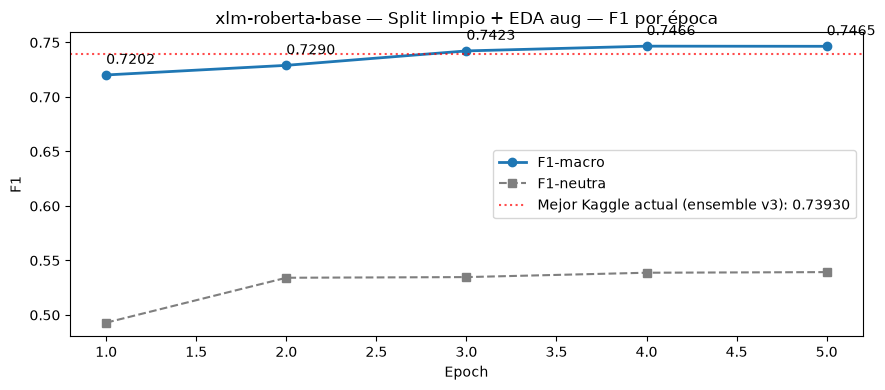

Mejor F1-macro (local, val limpio): 0.7466 en época 4
→ Score honesto, sin leakage sintético.
  Este modelo debería rendir similar en Kaggle.


In [10]:
history  = trainer.state.log_history
eval_f1  = [(x["epoch"], x["eval_f1_macro"]) for x in history if "eval_f1_macro" in x]
eval_neu = [(x["epoch"], x["eval_f1_neu"])   for x in history if "eval_f1_neu"   in x]

fig, ax = plt.subplots(figsize=(9, 4))
if eval_f1:
    epochs, f1s = zip(*eval_f1)
    ax.plot(epochs, f1s, marker="o", label="F1-macro", color="#1f77b4", linewidth=2)
    for e, f in zip(epochs, f1s):
        ax.annotate(f"{f:.4f}", (e, f), textcoords="offset points", xytext=(0, 8))
if eval_neu:
    epochs_n, f1s_n = zip(*eval_neu)
    ax.plot(epochs_n, f1s_n, marker="s", label="F1-neutra", color="#7f7f7f", linestyle="--")

ax.axhline(y=0.73930, color="red", linestyle=":", alpha=0.7,
           label="Mejor Kaggle actual (ensemble v3): 0.73930")
ax.set_xlabel("Epoch"); ax.set_ylabel("F1")
ax.set_title(f"{MODEL_NAME} — Split limpio + EDA aug — F1 por época")
ax.legend(); plt.tight_layout(); plt.show()

if eval_f1:
    best_ep, best_f1 = max(eval_f1, key=lambda x: x[1])
    print(f"Mejor F1-macro (local, val limpio): {best_f1:.4f} en época {best_ep:.0f}")
    if best_f1 >= 0.73:
        print("→ Score honesto, sin leakage sintético.")
        print("  Este modelo debería rendir similar en Kaggle.")

## 9. Guardado del modelo

In [11]:
SAVE_DIR = str(Path("../../../models") / SAVE_NAME)
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Modelo guardado en: {SAVE_DIR}")
print(f"Contenido: {list(Path(SAVE_DIR).iterdir())}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: ..\..\..\models\red_neuronal_xlm_roberta_n12_clean_split
Contenido: [WindowsPath('../../../models/red_neuronal_xlm_roberta_n12_clean_split/config.json'), WindowsPath('../../../models/red_neuronal_xlm_roberta_n12_clean_split/model.safetensors'), WindowsPath('../../../models/red_neuronal_xlm_roberta_n12_clean_split/tokenizer.json'), WindowsPath('../../../models/red_neuronal_xlm_roberta_n12_clean_split/tokenizer_config.json'), WindowsPath('../../../models/red_neuronal_xlm_roberta_n12_clean_split/training_args.bin')]


## 10. Submission individual (opcional)

Primero se reentrena sobre el dataset completo (train + val) para maximizar el rendimiento en Kaggle.
El modelo del ensemble se carga desde la carpeta guardada arriba (trained on train fold only).

In [12]:
# Reentrenar sobre train + val para submission individual
df_full = pd.concat([
    pd.DataFrame({"text": df_train_final["text"].values, "label": y_train_final}),
    pd.DataFrame({"text": X_val_raw, "label": y_val}),
], ignore_index=True)

X_full = np.array([clean_minimal(t) for t in df_full["text"].values])
y_full = df_full["label"].values.astype(int)

full_dataset = ResenasDataset(X_full, y_full, tokenizer, MAX_LENGTH)

# Usar el mismo NUM_EPOCHS que el mejor modelo encontrado con early stopping
best_epoch = int(trainer.state.best_model_checkpoint.split("-")[-1]) // (len(train_dataset) // BATCH_SIZE)
best_epoch = max(best_epoch, 1)
print(f"Mejor época (early stopping): {best_epoch} → reentrenando {best_epoch} epoch(s) sobre full data")

model_full = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True,
).to(DEVICE)

training_args_full = TrainingArguments(
    output_dir="./checkpoint_xlm_n12_full",
    num_train_epochs=best_epoch,
    per_device_train_batch_size=BATCH_SIZE,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=USE_FP16,
    logging_steps=100,
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

trainer_full = WeightedTrainer(
    class_weights=CLASS_WEIGHTS,
    model=model_full,
    args=training_args_full,
    train_dataset=full_dataset,
)

print(f"Reentrenando sobre {len(full_dataset):,} muestras (train+val)...")
trainer_full.train()
print("Listo.")

Mejor época (early stopping): 4 → reentrenando 4 epoch(s) sobre full data


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

Reentrenando sobre 67,000 muestras (train+val)...


Step,Training Loss
100,1.089080
200,1.023026
300,0.967667
400,0.815661
500,0.719772
600,0.687926
700,0.677876
800,0.699193
900,0.631947
1000,0.652707


Listo.


In [13]:
Path("submissions").mkdir(exist_ok=True)

preds_test  = trainer_full.predict(test_dataset)
y_test_pred = np.argmax(preds_test.predictions, axis=1)

sub_name = f"submission_{SAVE_NAME}.csv"
sub = pd.DataFrame({"id": test_df["id"].values, "label": y_test_pred.astype(int)})
sub.to_csv(f"submissions/{sub_name}", index=False)

dist = sub["label"].value_counts(normalize=True).sort_index()
print(f"Guardado: submissions/{sub_name} ({len(sub)} predicciones)")
print(f"Distribución: {', '.join(f'clase {k}: {v:.1%}' for k, v in dist.items())}")

Guardado: submissions/submission_red_neuronal_xlm_roberta_n12_clean_split.csv (8500 predicciones)
Distribución: clase 0: 37.5%, clase 1: 24.6%, clase 2: 38.0%
